<a href="https://colab.research.google.com/github/Chiozen/DesafioAluraTelecomX/blob/main/Desfio2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# PARTE 1: EXTRACCIÓN DE DATOS
# ==============================================================================
import pandas as pd
import requests

print("="*60)
print(" PARTE 1: EXTRACCIÓN DE DATOS DESDE LA API ")
print("="*60)

# 1. Enlace de la API proporcionado en las instrucciones (versión raw)
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("Estableciendo conexión con el repositorio de ingridcristh...")

try:
    # ✅ Cargar los datos directamente desde la API utilizando Python
    respuesta = requests.get(url_api, timeout=10)
    respuesta.raise_for_status() # Valida que la conexión sea exitosa (código 200)
    datos_crudos = respuesta.json()

    # ✅ Convertir los datos a un DataFrame de Pandas para su manipulación
    # Usamos json_normalize para "aplanar" la información anidada del JSON
    df_telecom = pd.json_normalize(datos_crudos)

    # --- RESULTADOS ESPERADOS ---
    print("\nRESULTADO ESPERADO PARTE 1:")
    print(f"-> ✓ Conexión y descarga exitosa.")
    print(f"-> ✓ DataFrame generado con {df_telecom.shape[0]} filas y {df_telecom.shape[1]} columnas.")
    print("-> Muestra de los datos convertidos a Pandas:\n")

    display(df_telecom.head(3))

except requests.exceptions.RequestException as e:
    print(f"Error crítico al intentar conectar con la API: {e}")

 PARTE 1: EXTRACCIÓN DE DATOS DESDE LA API 
Estableciendo conexión con el repositorio de ingridcristh...

RESULTADO ESPERADO PARTE 1:
-> ✓ Conexión y descarga exitosa.
-> ✓ DataFrame generado con 7267 filas y 21 columnas.
-> Muestra de los datos convertidos a Pandas:



,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [ ]:
# ==============================================================================
# PARTE 2: TRANSFORMACIÓN Y LIMPIEZA DE DATOS
# ==============================================================================
import pandas as pd
import numpy as np

print("="*60)
print(" PARTE 2: EJECUCIÓN DE TAREAS DE TRANSFORMACIÓN ")
print("="*60)

# Asumimos que df_telecom es el DataFrame generado en la Parte 1

# --- PRE-PASO: Limpieza de nombres de columnas para facilitar la exploración ---
for prefijo in ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']:
    df_telecom.columns = df_telecom.columns.str.replace(prefijo, '', regex=False)
df_telecom.columns = df_telecom.columns.str.lower()


# ✅ TAREA 1: CONOCE EL CONJUNTO DE DATOS
print("\n[ TAREA 1: CONOCE EL CONJUNTO DE DATOS ]")
print("-> Ejecutando df_telecom.info() para verificar tipos de datos:")
# info() nos muestra los tipos de datos y si hay nulos evidentes
print(df_telecom.info())


# ✅ TAREA 2: COMPROBACIÓN DE INCOHERENCIAS EN LOS DATOS
print("\n[ TAREA 2: COMPROBACIÓN DE INCOHERENCIAS ]")
# Usamos unique() para buscar valores extraños en la variable objetivo
print("-> Valores únicos iniciales en 'churn':", df_telecom['churn'].unique())

# Incoherencia 1: Eliminamos los registros anómalos (vacíos) en la columna churn
registros_antes = len(df_telecom)
df_telecom = df_telecom[df_telecom['churn'].isin(['Yes', 'No'])].copy()

# Incoherencia 2: 'total' viene como texto (object) por culpa de espacios en blanco.
# Lo forzamos a numérico y rellenamos esos vacíos con 0.0
df_telecom['total'] = pd.to_numeric(df_telecom['total'], errors='coerce').fillna(0.0)

print(f"-> ✓ Incoherencias corregidas. Se eliminaron {registros_antes - len(df_telecom)} filas sin datos de evasión.")
print("-> ✓ La columna 'total' ha sido convertida a tipo numérico (float64).")


# ✅ TAREA 3: COLUMNA DE CUENTAS DIARIAS (Opcional)
print("\n[ TAREA 3: CREACIÓN DE COLUMNA 'CUENTAS_DIARIAS' ]")
# Calculamos el gasto diario dividiendo la facturación mensual ('monthly') entre 30 días
df_telecom['cuentas_diarias'] = round(df_telecom['monthly'] / 30, 2)
print("-> ✓ Columna 'cuentas_diarias' generada con éxito.")


# ✅ TAREA 4: ESTANDARIZACIÓN Y TRANSFORMACIÓN DE DATOS (Opcional)
print("\n[ TAREA 4: ESTANDARIZACIÓN Y TRANSFORMACIÓN ]")

# 4.1 Traducción de valores categóricos para mejor legibilidad
traducciones = {
    'Yes': 'Sí', 'No': 'No',
    'Male': 'Masculino', 'Female': 'Femenino',
    'No internet service': 'Sin internet', 'No phone service': 'Sin teléfono',
    'Month-to-month': 'Mensual', 'One year': '1 Año', 'Two year': '2 Años',
    'Bank transfer (automatic)': 'Transferencia', 'Credit card (automatic)': 'Tarjeta',
    'Electronic check': 'Cheque electrónico', 'Mailed check': 'Cheque por correo'
}
df_telecom = df_telecom.replace(traducciones)

# 4.2 Transformación a valores binarios para Machine Learning
df_telecom['churn_binario'] = df_telecom['churn'].map({'Sí': 1, 'No': 0})
print("-> ✓ Datos traducidos al español.")
print("-> ✓ Columna 'churn_binario' (1 y 0) creada para facilitar el modelado analítico.")

# --- RESULTADO FINAL DE LA PARTE 2 ---
print("\nRESULTADO ESPERADO PARTE 2 (Muestra de columnas clave):")
display(df_telecom[['customerid', 'monthly', 'cuentas_diarias', 'churn', 'churn_binario']].head())

 PARTE 2: EJECUCIÓN DE TAREAS DE TRANSFORMACIÓN 

[ TAREA 1: CONOCE EL CONJUNTO DE DATOS ]
-> Ejecutando df_telecom.info() para verificar tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   object 
 5   dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   object 
 8   multiplelines     7267 non-null   object 
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   object 
 11  onlinebackup      7267 non-null   object 
 12  deviceprotection  7267 non-null   object 
 13  techsupport       7267 non-nu

,customerid,monthly,cuentas_diarias,churn,churn_binario
0,0002-ORFBO,65.6,2.19,No,0
1,0003-MKNFE,59.9,2.00,No,0
2,0004-TLHLJ,73.9,2.46,Sí,1
3,0011-IGKFF,98.0,3.27,Sí,1
4,0013-EXCHZ,83.9,2.80,Sí,1


 PARTE 3: EJECUCIÓN DE ANÁLISIS EXPLORATORIO (EDA) 

[ TAREA 1: ANÁLISIS DESCRIPTIVO ]
-> Estadísticas de las variables numéricas (media, mediana, desviación):


,tenure,monthly,total,cuentas_diarias
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.16
std,24.56,30.09,2266.79,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.50,398.55,1.18
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,2.99
max,72.00,118.75,8684.80,3.96



-> Estadísticas de las variables categóricas principales:


,gender,contract,paymentmethod,churn
count,7043,7043,7043,7043
unique,2,3,4,2
top,Masculino,Mensual,Cheque electrónico,No
freq,3555,3875,2365,5174



[ GENERANDO PANEL VISUAL PARA TAREAS 2, 3 Y 4... ]


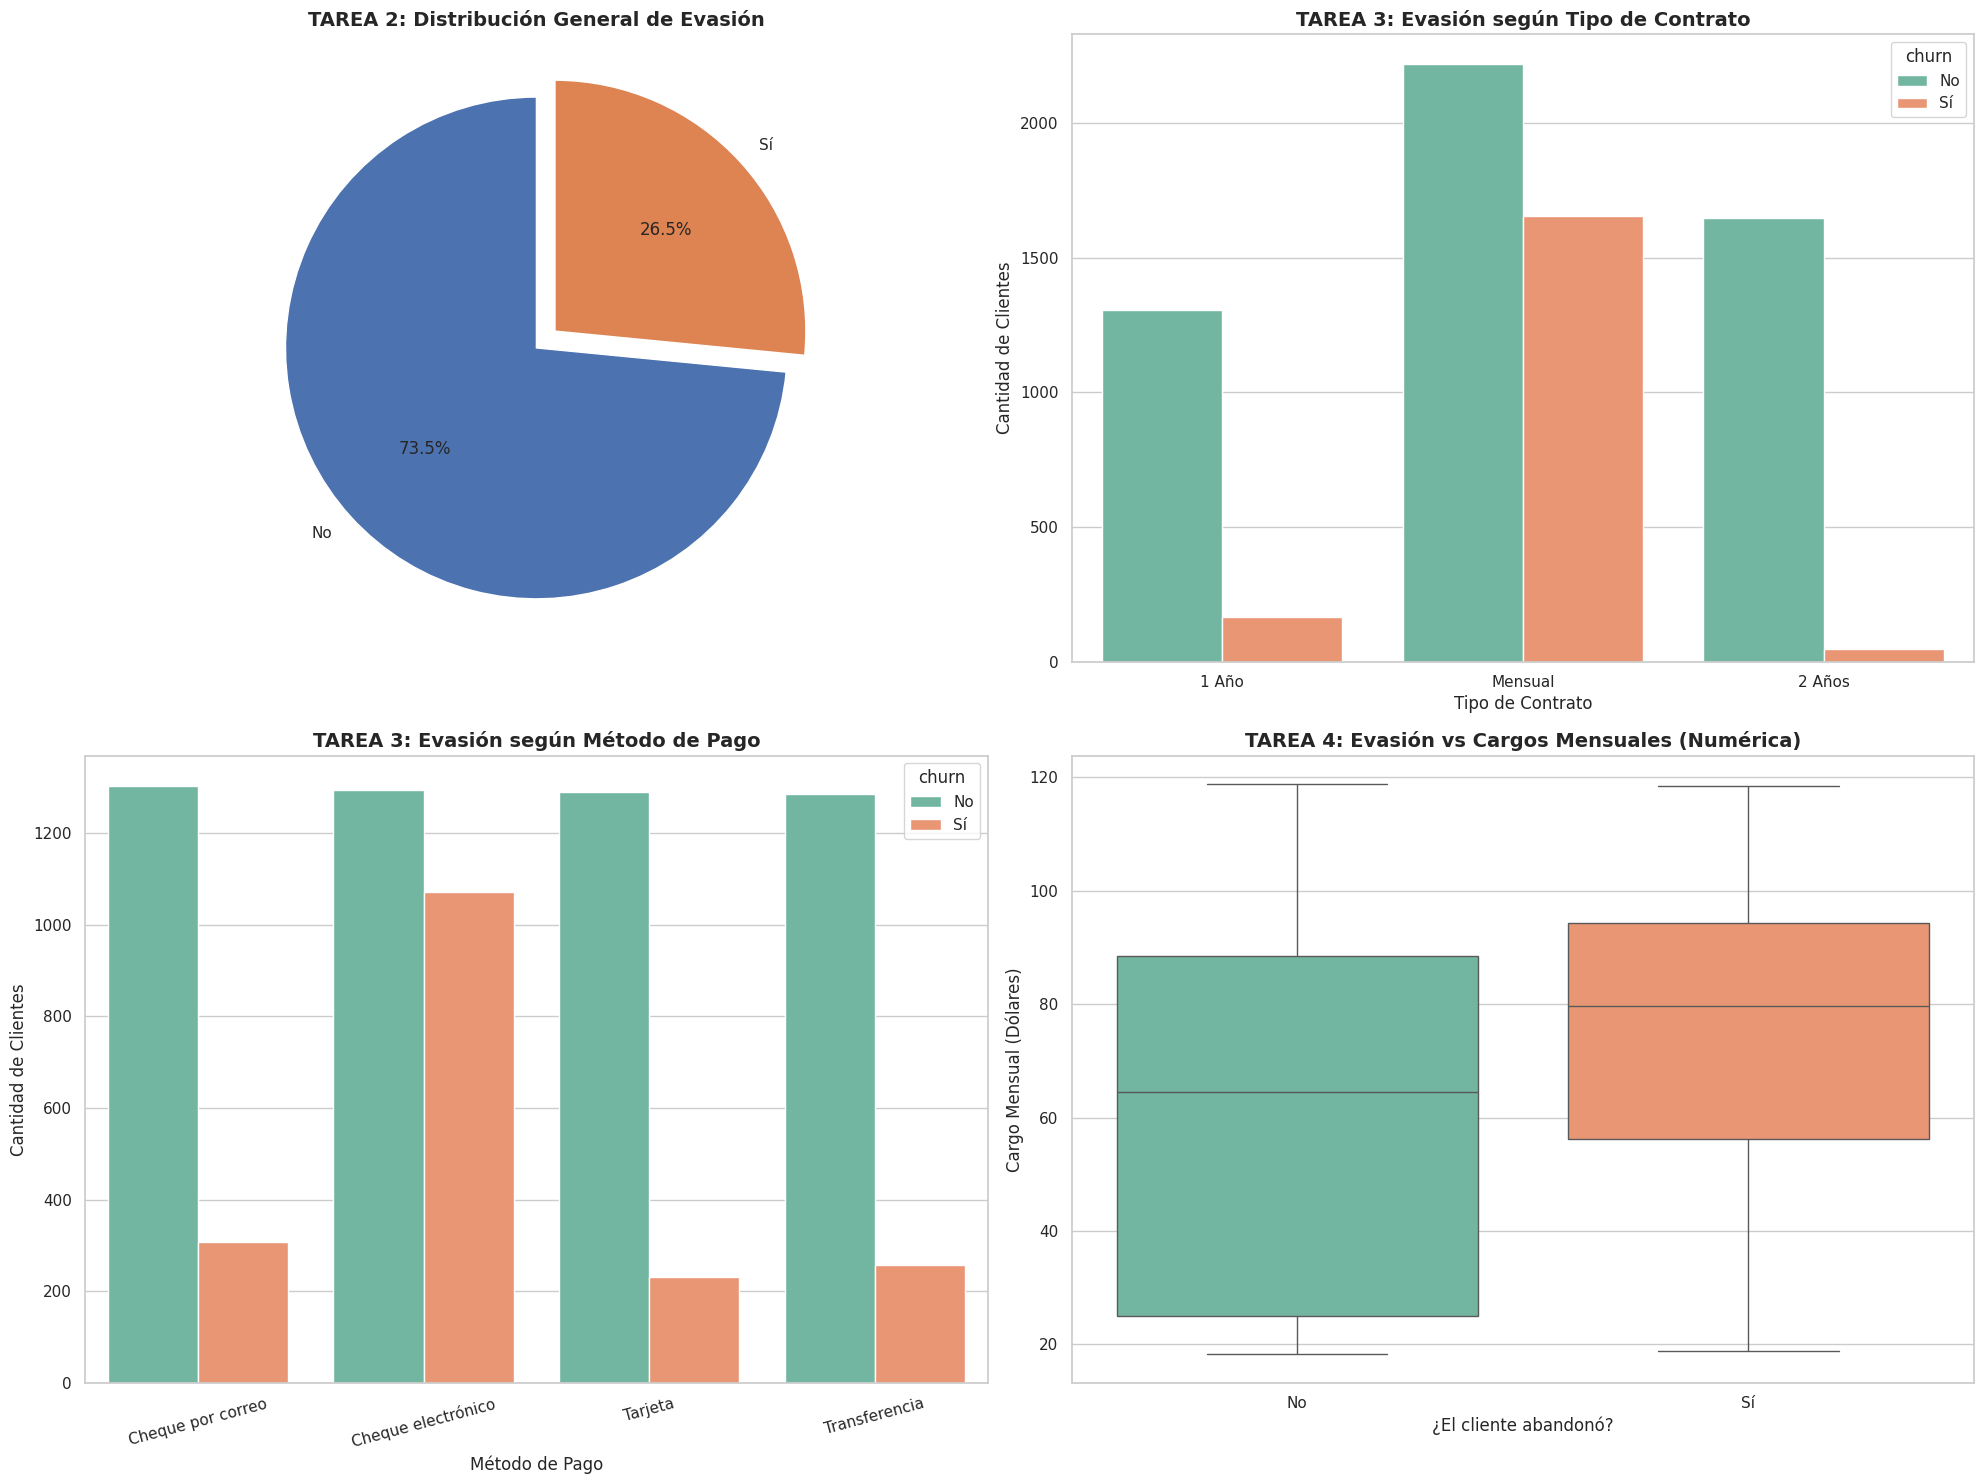


✓ Análisis Exploratorio finalizado con éxito y sin advertencias.


In [ ]:
# ==============================================================================
# PARTE 3: CARGA Y ANÁLISIS EXPLORATORIO (EDA)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" PARTE 3: EJECUCIÓN DE ANÁLISIS EXPLORATORIO (EDA) ")
print("="*60)

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# ✅ TAREA 1: ANÁLISIS DESCRIPTIVO
print("\n[ TAREA 1: ANÁLISIS DESCRIPTIVO ]")
print("-> Estadísticas de las variables numéricas (media, mediana, desviación):")
display(df_telecom[['tenure', 'monthly', 'total', 'cuentas_diarias']].describe().round(2))

print("\n-> Estadísticas de las variables categóricas principales:")
display(df_telecom[['gender', 'contract', 'paymentmethod', 'churn']].describe())


# ==============================================================================
# PREPARACIÓN DEL PANEL VISUAL (DASHBOARD)
# ==============================================================================
print("\n[ GENERANDO PANEL VISUAL PARA TAREAS 2, 3 Y 4... ]")
fig = plt.figure(figsize=(20, 15))

# ✅ TAREA 2: DISTRIBUCIÓN DE EVASIÓN (CHURN)
ax1 = plt.subplot(2, 2, 1)
churn_counts = df_telecom['churn'].value_counts()
ax1.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#4C72B0', '#DD8452'], explode=[0, 0.1])
ax1.set_title('TAREA 2: Distribución General de Evasión', fontsize=14, fontweight='bold')


# ✅ TAREA 3: RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS
ax2 = plt.subplot(2, 2, 2)
sns.countplot(data=df_telecom, x='contract', hue='churn', palette='Set2', ax=ax2)
ax2.set_title('TAREA 3: Evasión según Tipo de Contrato', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tipo de Contrato')
ax2.set_ylabel('Cantidad de Clientes')

ax3 = plt.subplot(2, 2, 3)
sns.countplot(data=df_telecom, x='paymentmethod', hue='churn', palette='Set2', ax=ax3)
ax3.set_title('TAREA 3: Evasión según Método de Pago', fontsize=14, fontweight='bold')
ax3.set_xlabel('Método de Pago')
ax3.set_ylabel('Cantidad de Clientes')
ax3.tick_params(axis='x', rotation=15)


# ✅ TAREA 4: CONTEO DE EVASIÓN POR VARIABLES NUMÉRICAS
ax4 = plt.subplot(2, 2, 4)
# CORRECCIÓN APLICADA AQUÍ: Se añade hue='churn' y legend=False
sns.boxplot(data=df_telecom, x='churn', y='monthly', hue='churn', palette='Set2', legend=False, ax=ax4)
ax4.set_title('TAREA 4: Evasión vs Cargos Mensuales (Numérica)', fontsize=14, fontweight='bold')
ax4.set_xlabel('¿El cliente abandonó?')
ax4.set_ylabel('Cargo Mensual (Dólares)')

plt.tight_layout()
plt.show()

print("\n✓ Análisis Exploratorio finalizado con éxito y sin advertencias.")